<a href="https://colab.research.google.com/github/rohit-arunn/housepriceprediction/blob/main/theprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
dftrain = pd.read_csv("train.csv")
dftest = pd.read_csv("test.csv")
dftrain.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [24]:
X = dftrain.drop("SalePrice", axis=1)  # features
y = dftrain["SalePrice"]

In [25]:
X.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


In [26]:
print(X.shape)
X.isna().sum()[X.isna().sum() > 0]


(1460, 80)


,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [27]:
X = X.drop(["Alley", "PoolQC", "Fence", "MiscFeature"], axis=1)

In [28]:
X.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,61,0,0,0,0,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,42,0,0,0,0,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,84,0,0,0,0,0,12,2008,WD,Normal


In [33]:
X["ScreenPorch"].head()

,ScreenPorch
0,0
1,0
2,0
3,0
4,0


Generating scatter plots for 36 numerical features against SalePrice...


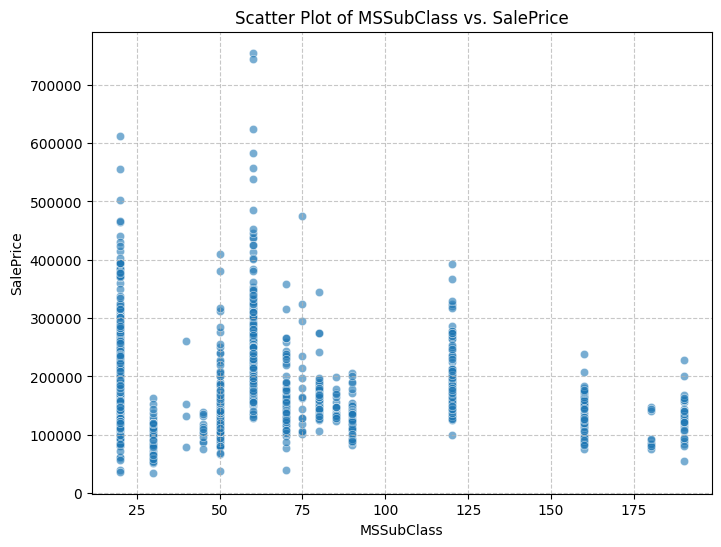

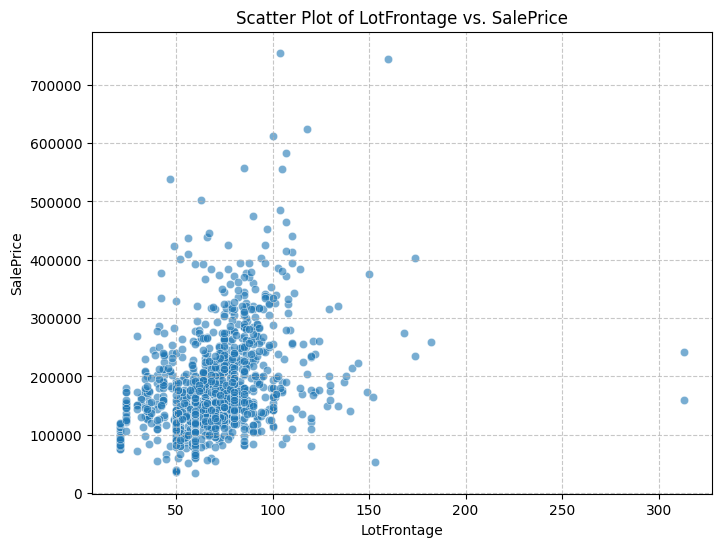

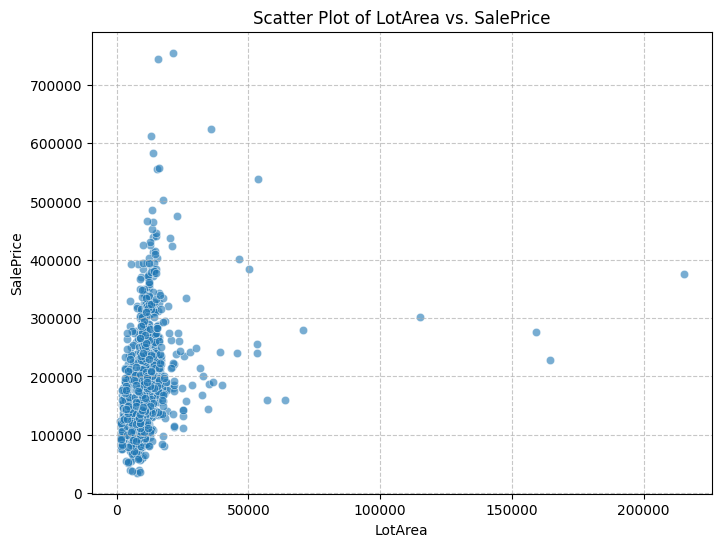

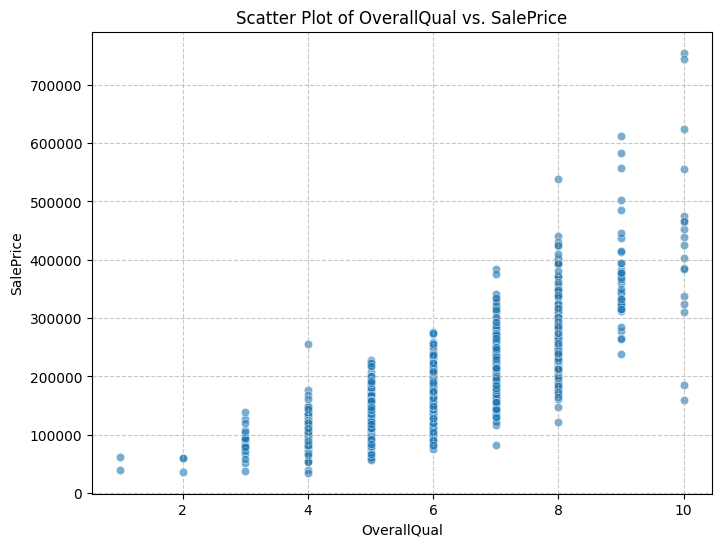

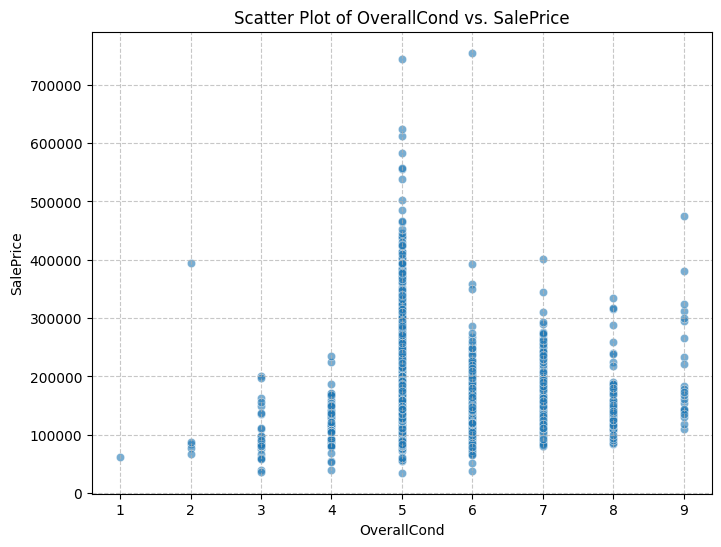

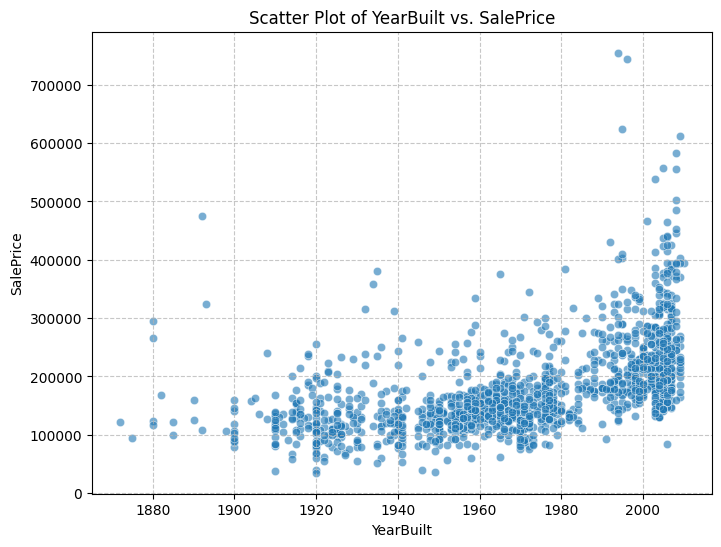

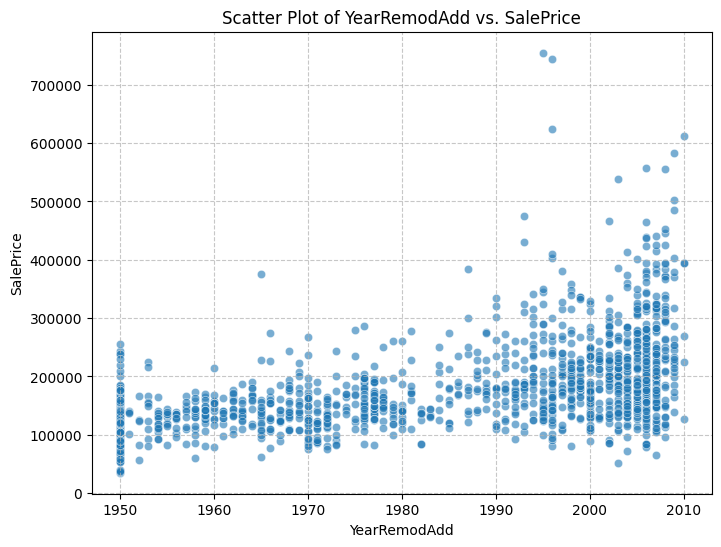

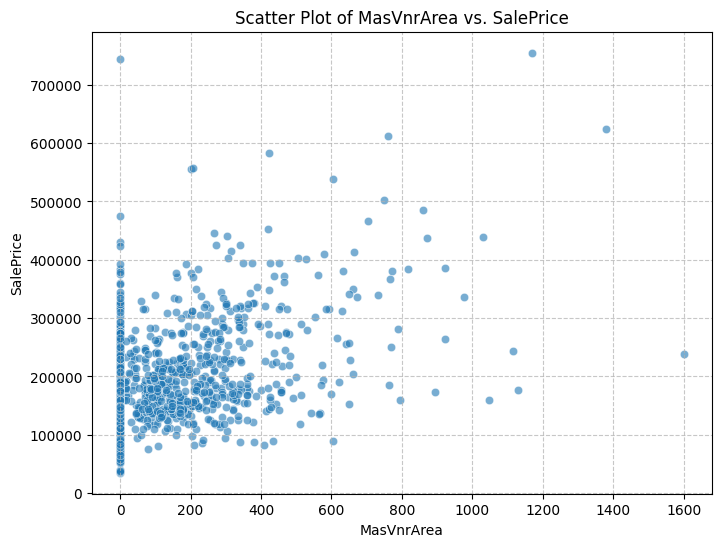

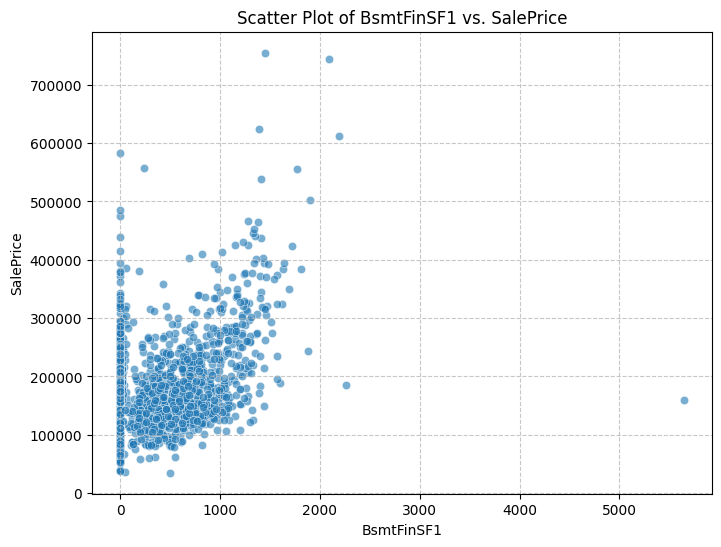

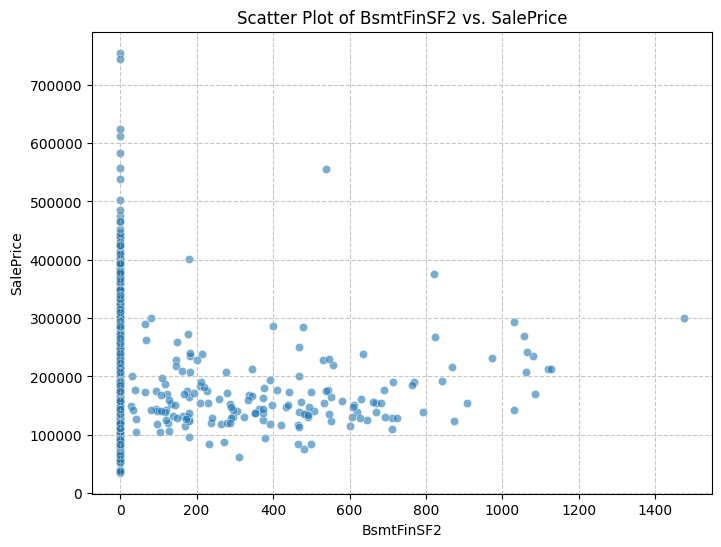

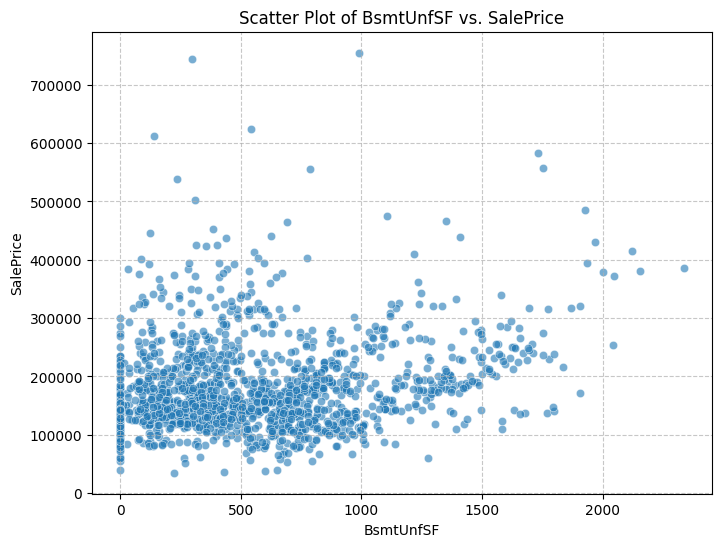

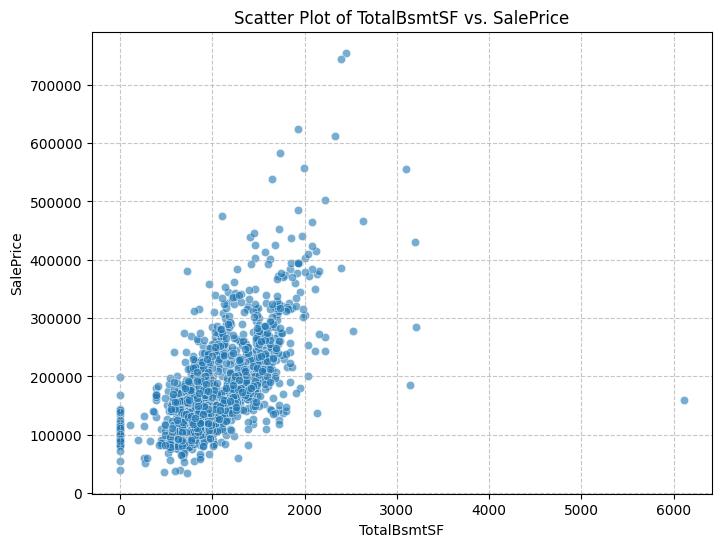

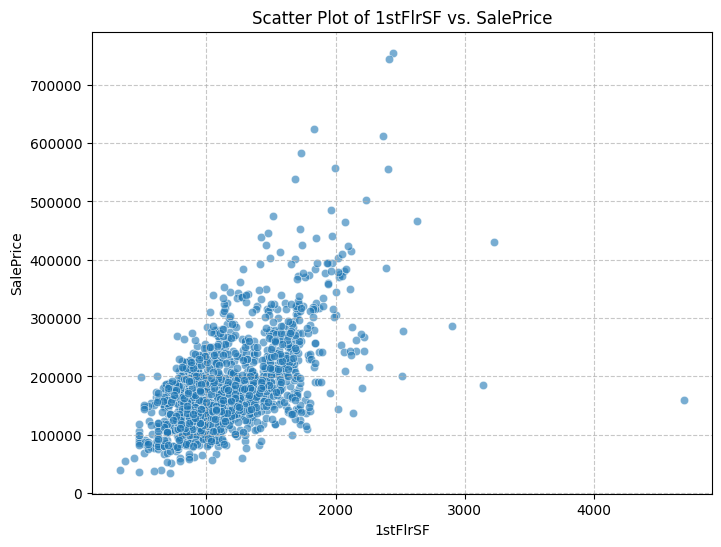

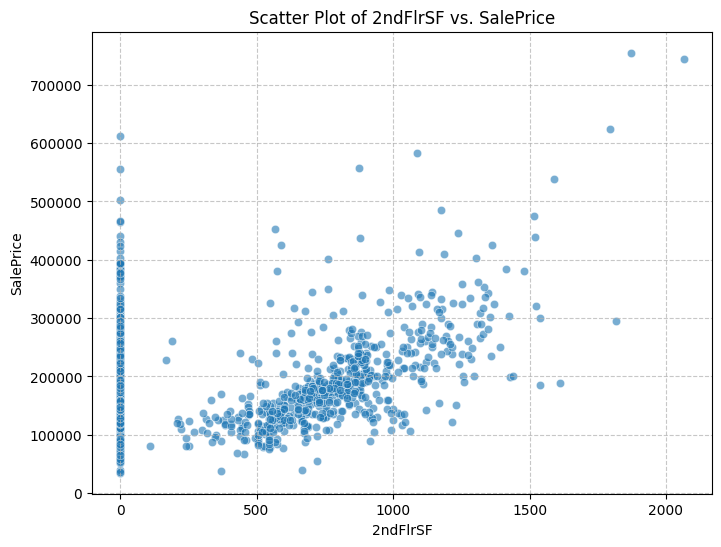

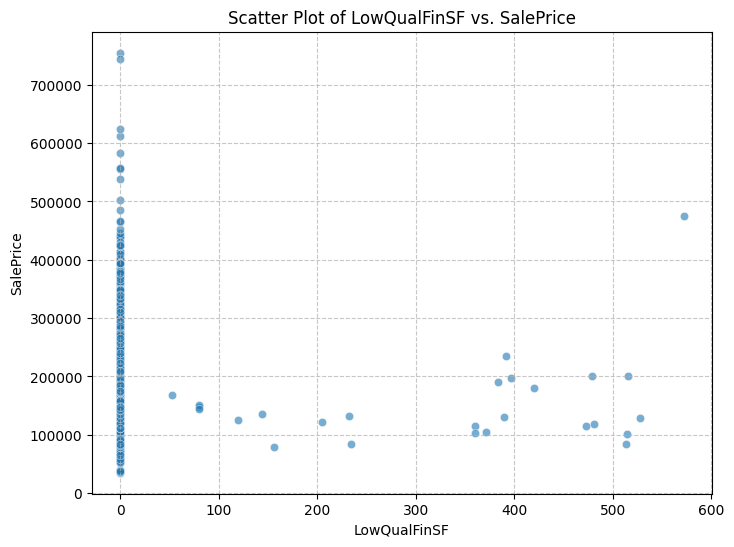

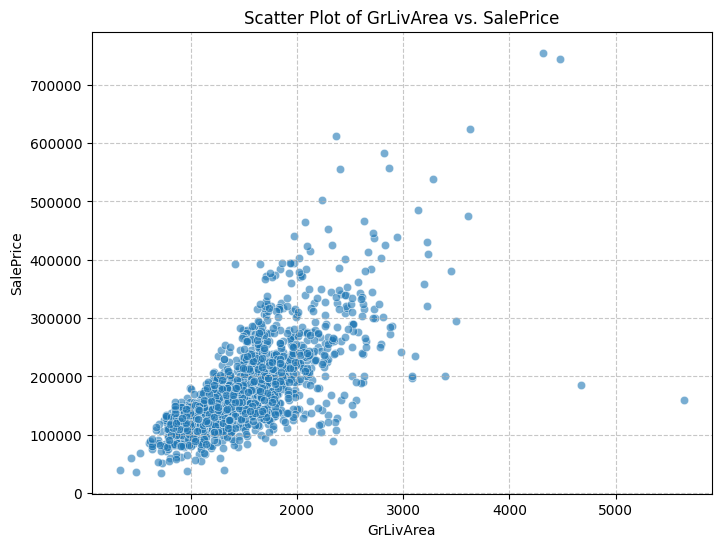

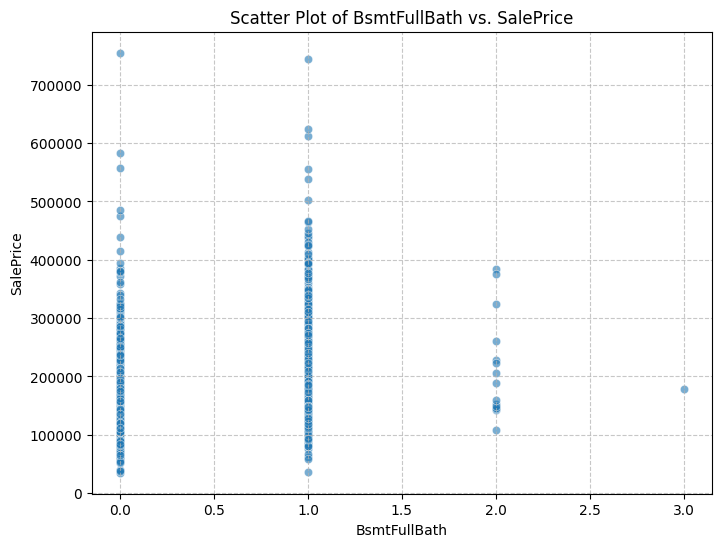

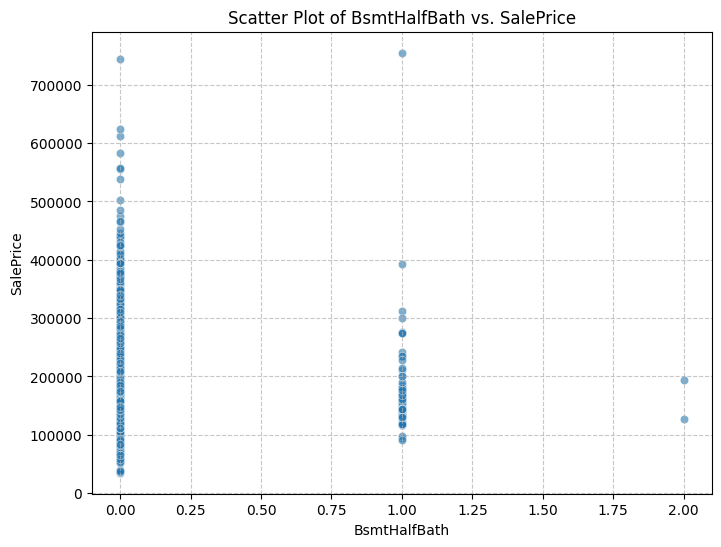

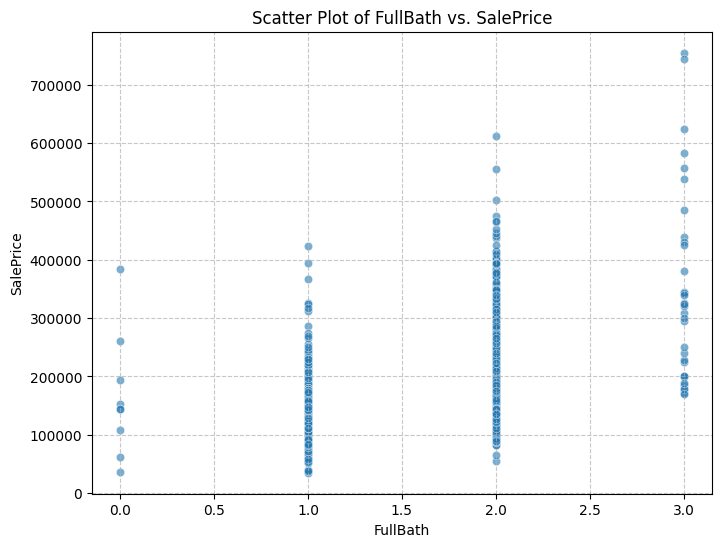

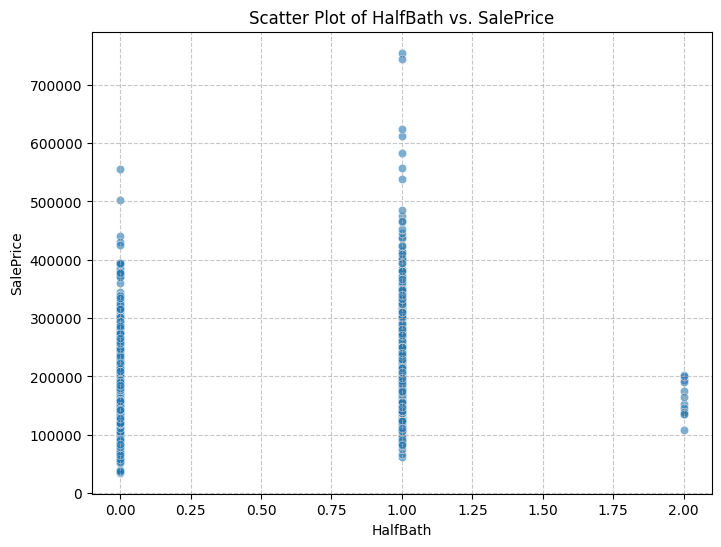

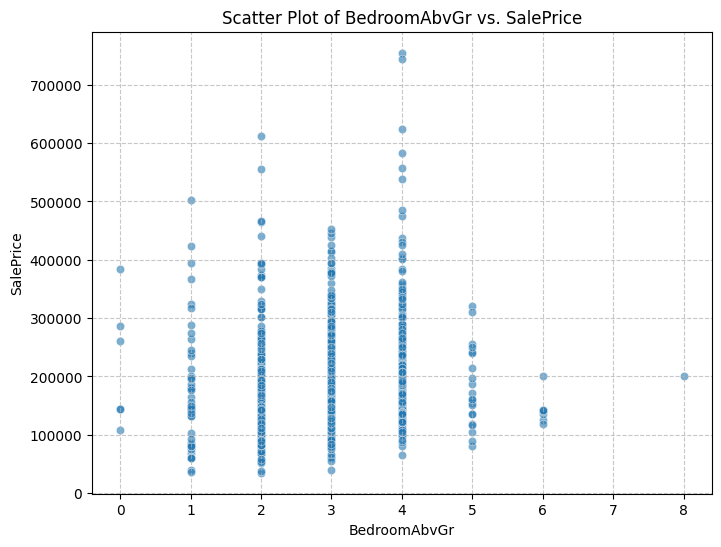

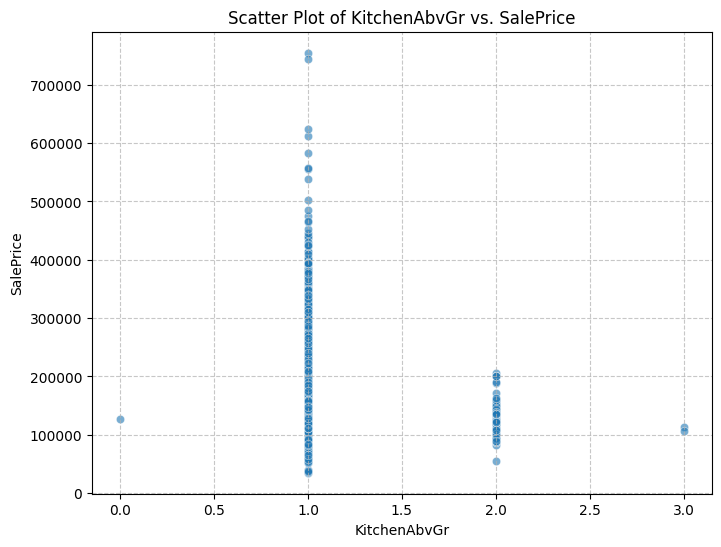

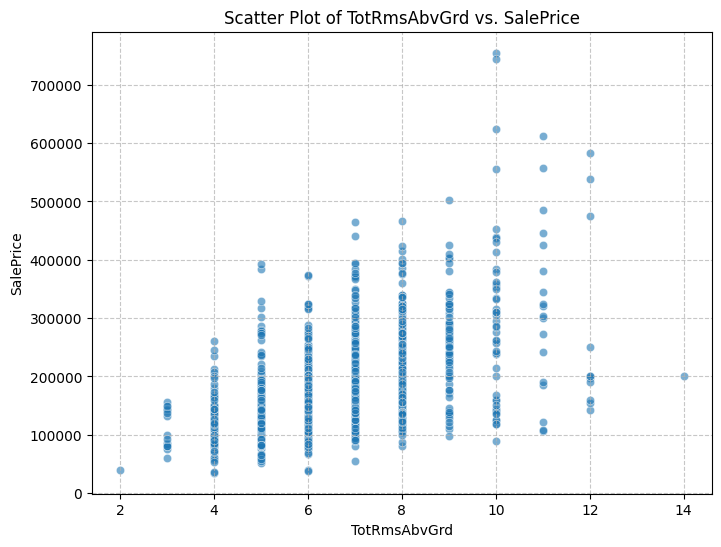

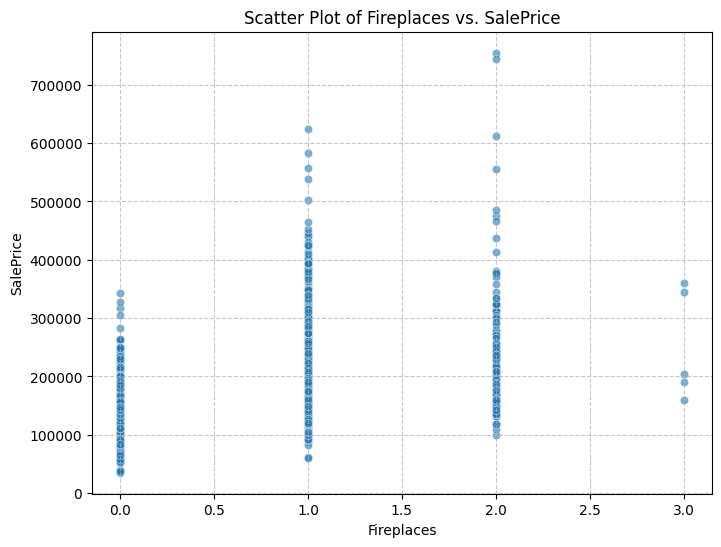

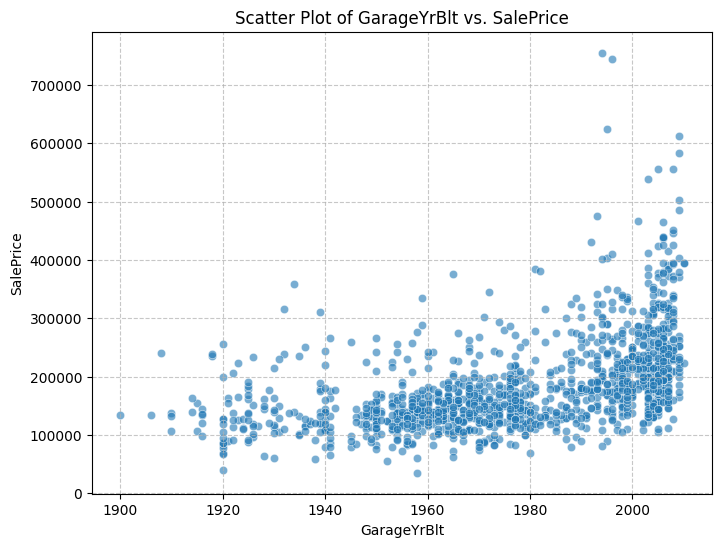

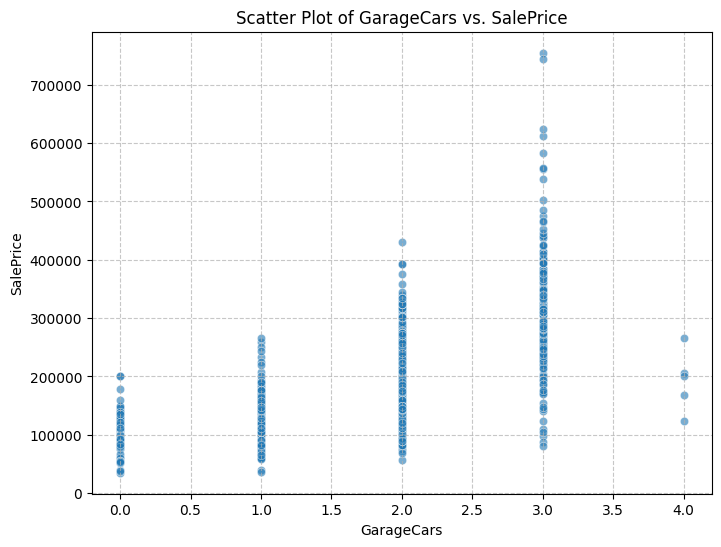

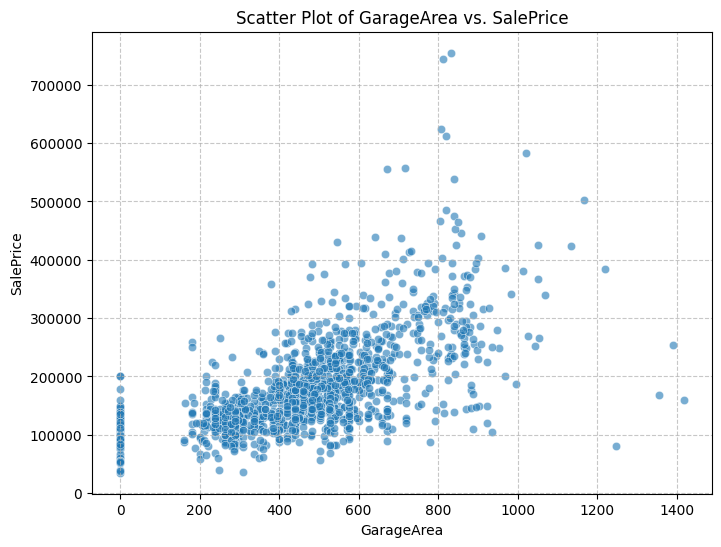

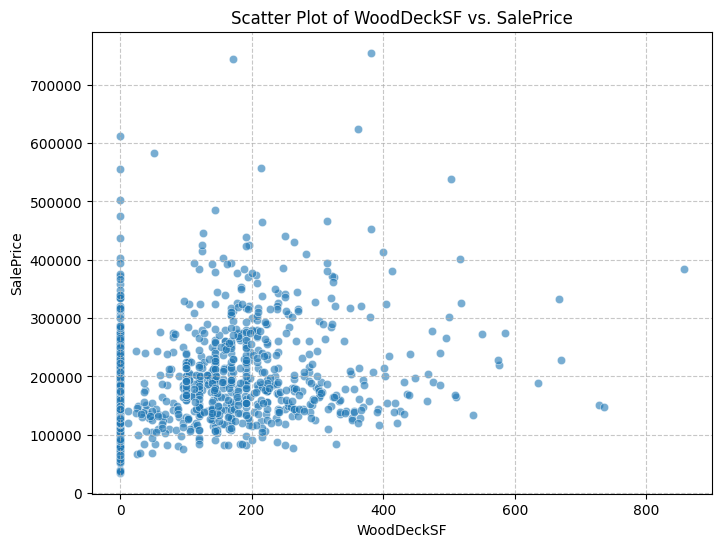

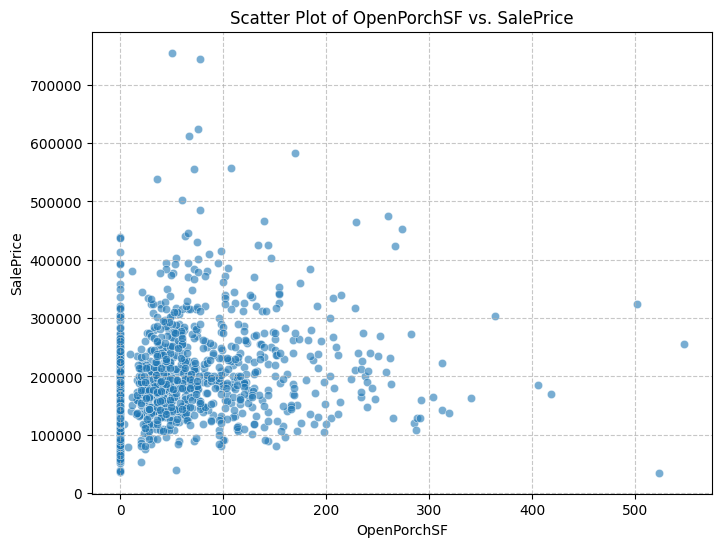

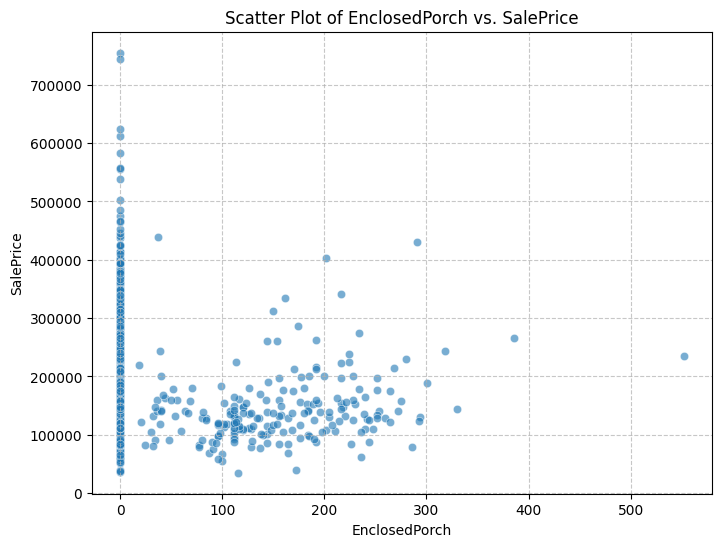

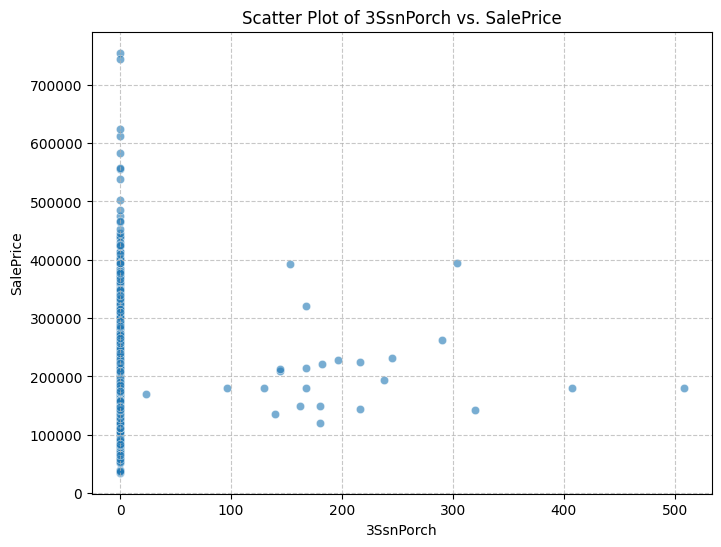

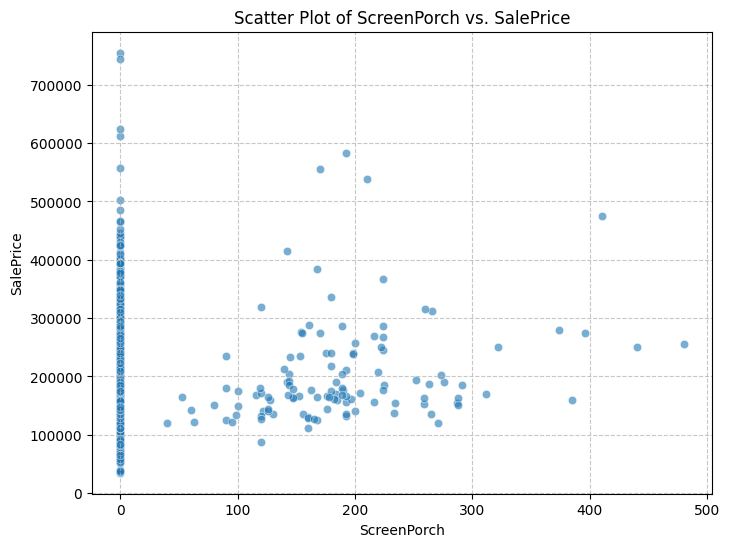

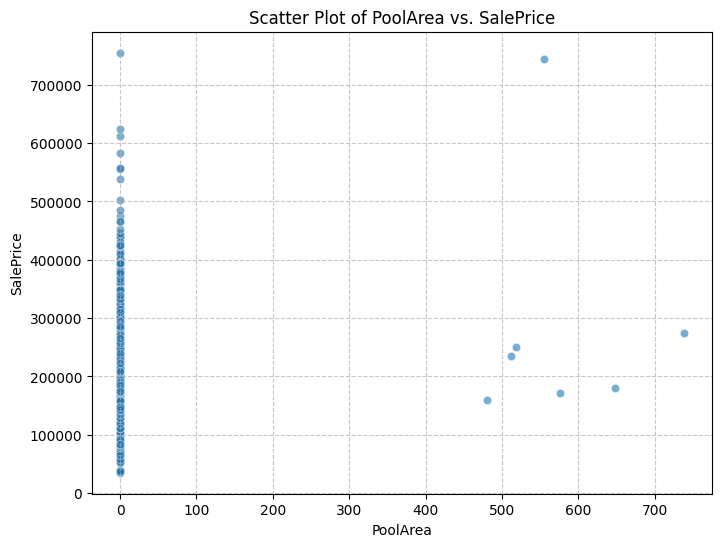

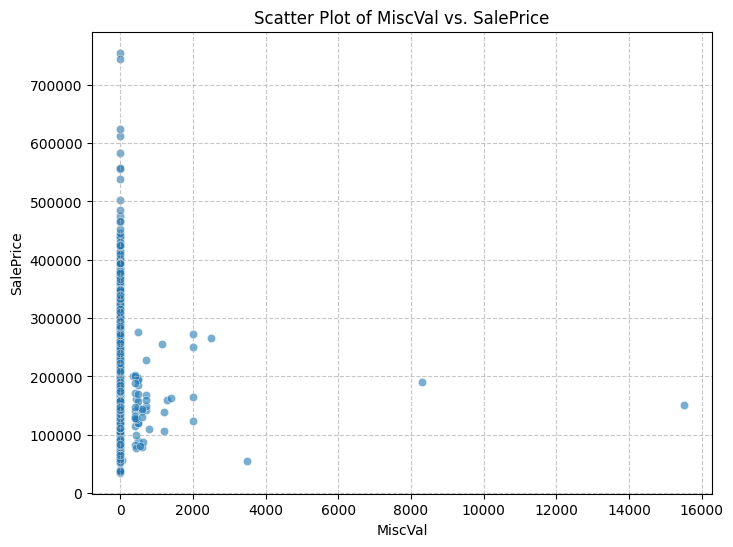

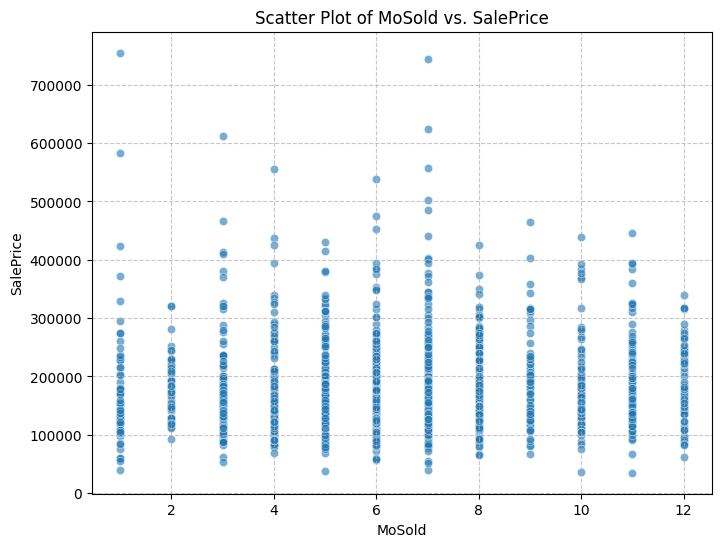

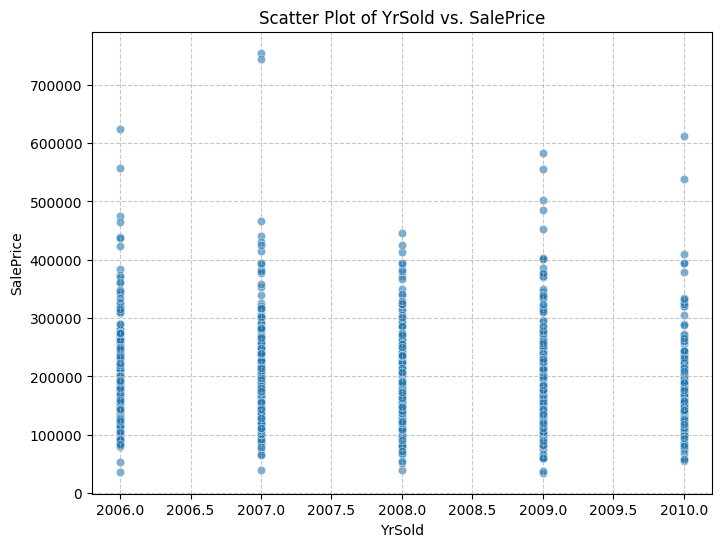

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns in X
numerical_cols = X.select_dtypes(include=np.number).columns

# Exclude 'Id' as it's just an identifier and won't have a meaningful correlation
numerical_cols = numerical_cols.drop('Id', errors='ignore')

print(f"Generating scatter plots for {len(numerical_cols)} numerical features against SalePrice...")

# Create scatter plots for each numerical column against the target variable y
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X[col], y=y, alpha=0.6)
    plt.title(f'Scatter Plot of {col} vs. SalePrice')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [35]:
unique_values_data = {}
for col in X.select_dtypes(include='object').columns:
    unique_values_data[col] = list(X[col].unique())

# Create a DataFrame for better display
# Since unique value lists can have different lengths, pad with None or use a different structure
# For simplicity, let's create a dictionary of columns to lists
unique_values_df = pd.DataFrame({
    'Column Name': unique_values_data.keys(),
    'Unique Values': unique_values_data.values()
})

display(unique_values_df)

,Column Name,Unique Values
0,MSZoning,"[RL, RM, C (all), FV, RH]"
1,Street,"[Pave, Grvl]"
2,LotShape,"[Reg, IR1, IR2, IR3]"
3,LandContour,"[Lvl, Bnk, Low, HLS]"
4,Utilities,"[AllPub, NoSeWa]"
5,LotConfig,"[Inside, FR2, Corner, CulDSac, FR3]"
6,LandSlope,"[Gtl, Mod, Sev]"
7,Neighborhood,"[CollgCr, Veenker, Crawfor, NoRidge, Mitchel, ..."
8,Condition1,"[Norm, Feedr, PosN, Artery, RRAe, RRNn, RRAn, ..."
9,Condition2,"[Norm, Artery, RRNn, Feedr, PosN, PosA, RRAn, ..."


In [34]:
for col in X.select_dtypes(include='object').columns:
    print(f"Column '{col}': {X[col].nunique()} unique values")

Column 'MSZoning': 5 unique values
Column 'Street': 2 unique values
Column 'LotShape': 4 unique values
Column 'LandContour': 4 unique values
Column 'Utilities': 2 unique values
Column 'LotConfig': 5 unique values
Column 'LandSlope': 3 unique values
Column 'Neighborhood': 25 unique values
Column 'Condition1': 9 unique values
Column 'Condition2': 8 unique values
Column 'BldgType': 5 unique values
Column 'HouseStyle': 8 unique values
Column 'RoofStyle': 6 unique values
Column 'RoofMatl': 8 unique values
Column 'Exterior1st': 15 unique values
Column 'Exterior2nd': 16 unique values
Column 'MasVnrType': 3 unique values
Column 'ExterQual': 4 unique values
Column 'ExterCond': 5 unique values
Column 'Foundation': 6 unique values
Column 'BsmtQual': 4 unique values
Column 'BsmtCond': 4 unique values
Column 'BsmtExposure': 4 unique values
Column 'BsmtFinType1': 6 unique values
Column 'BsmtFinType2': 6 unique values
Column 'Heating': 6 unique values
Column 'HeatingQC': 5 unique values
Column 'Centr